# Spatial Foundation Visualizations
B-spline basis functions and Gaussian quadrature for the spherically symmetric NSK solver.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.bsplines import make_knot_vector, basis_matrix, basis_deriv_matrix
from src.quadrature import quadrature_points, recommended_n_gauss

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})

## Plot 1: Basis Functions and Their Derivatives
Shows the partition of unity and the smoothness required to evaluate the Korteweg stress (needs $d^2\rho/dr^2$, requires $p \geq 2$).

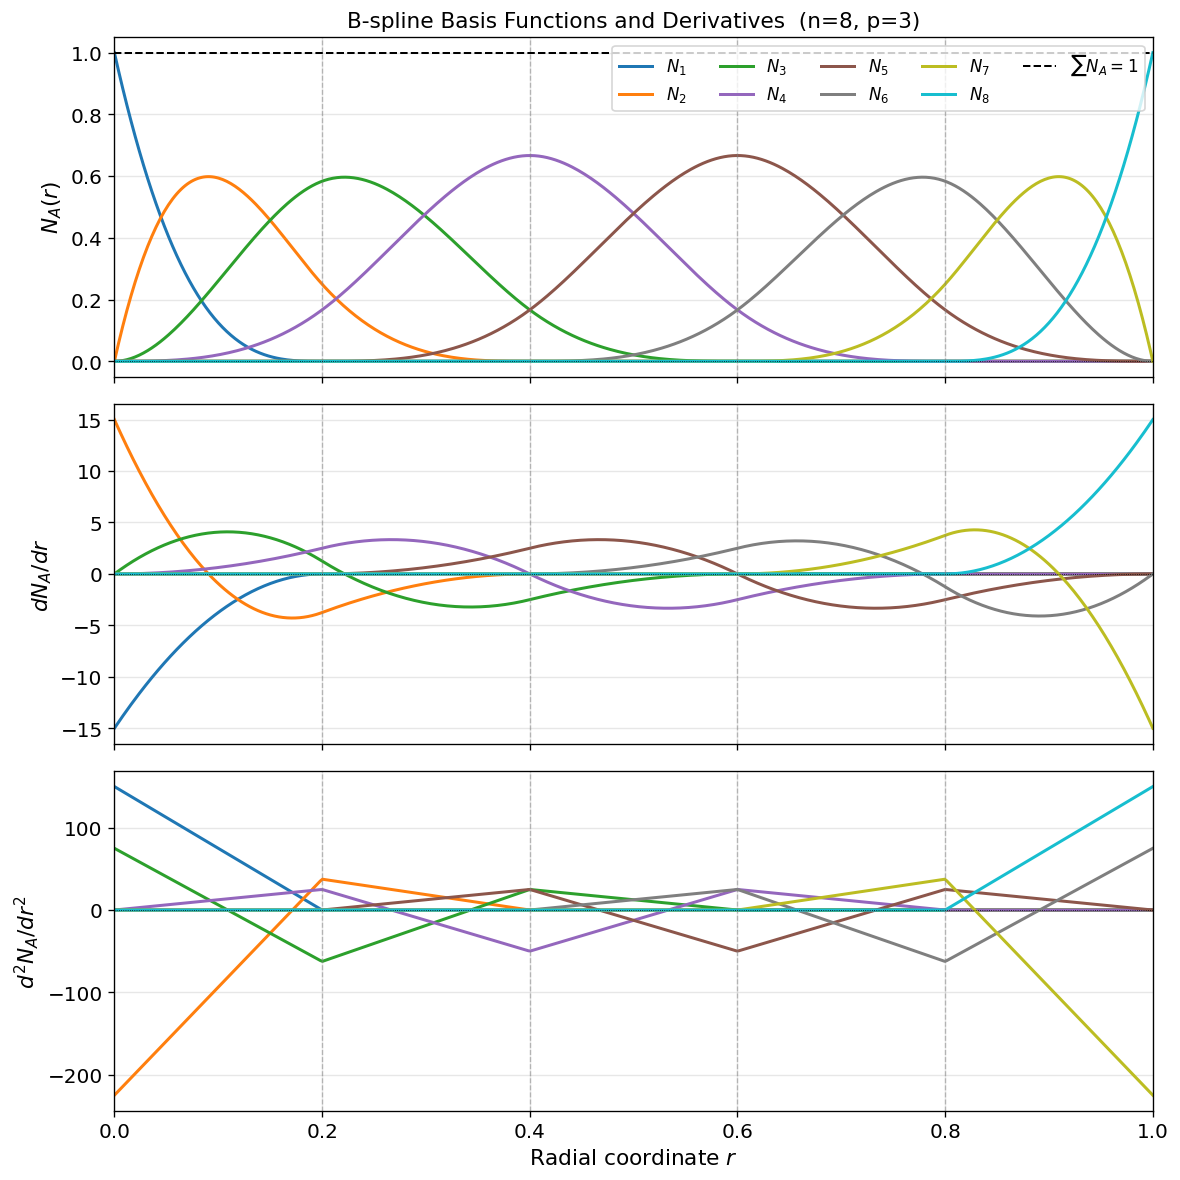

In [2]:
n_ctrl = 8
degree = 3
R_max  = 1.0

t   = make_knot_vector(n_ctrl, degree)
xi  = jnp.linspace(0.0, 1.0, 500)
r   = R_max * xi

N   = np.asarray(basis_matrix(xi, t, degree))                        # (500, n_ctrl)
dN  = np.asarray(basis_deriv_matrix(xi, t, degree, order=1)) / R_max # chain rule: dN/dr
d2N = np.asarray(basis_deriv_matrix(xi, t, degree, order=2)) / R_max**2

knot_locs = R_max * np.unique(np.asarray(t))
r_np      = np.asarray(r)
colors    = plt.cm.tab10(np.linspace(0, 1, n_ctrl))

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for A in range(n_ctrl):
    axes[0].plot(r_np, N[:, A],   color=colors[A], lw=1.8, label=f'$N_{{{A+1}}}$')
    axes[1].plot(r_np, dN[:, A],  color=colors[A], lw=1.8)
    axes[2].plot(r_np, d2N[:, A], color=colors[A], lw=1.8)

for ax in axes:
    for xk in knot_locs[1:-1]:
        ax.axvline(xk, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xlim(0, R_max)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$N_A(r)$')
axes[1].set_ylabel('$dN_A/dr$')
axes[2].set_ylabel('$d^2N_A/dr^2$')
axes[2].set_xlabel('Radial coordinate $r$')
axes[0].legend(ncol=4, loc='upper right')
axes[0].set_title(f'B-spline Basis Functions and Derivatives  (n={n_ctrl}, p={degree})')

# Annotate partition of unity
sum_N = N.sum(axis=1)
axes[0].plot(r_np, sum_N, 'k--', lw=1.2, label='$\\sum N_A = 1$')
axes[0].legend(ncol=5, loc='upper right')

plt.tight_layout()
plt.savefig('../figures/plot1_basis_functions.png', bbox_inches='tight')
plt.show()

## Plot 2: Bubble Density Field Reconstruction
Synthetic bubble profile: liquid density outside, vapor inside, sharp interface. Shows how well B-splines capture the steep gradient and how derivatives look at the interface.

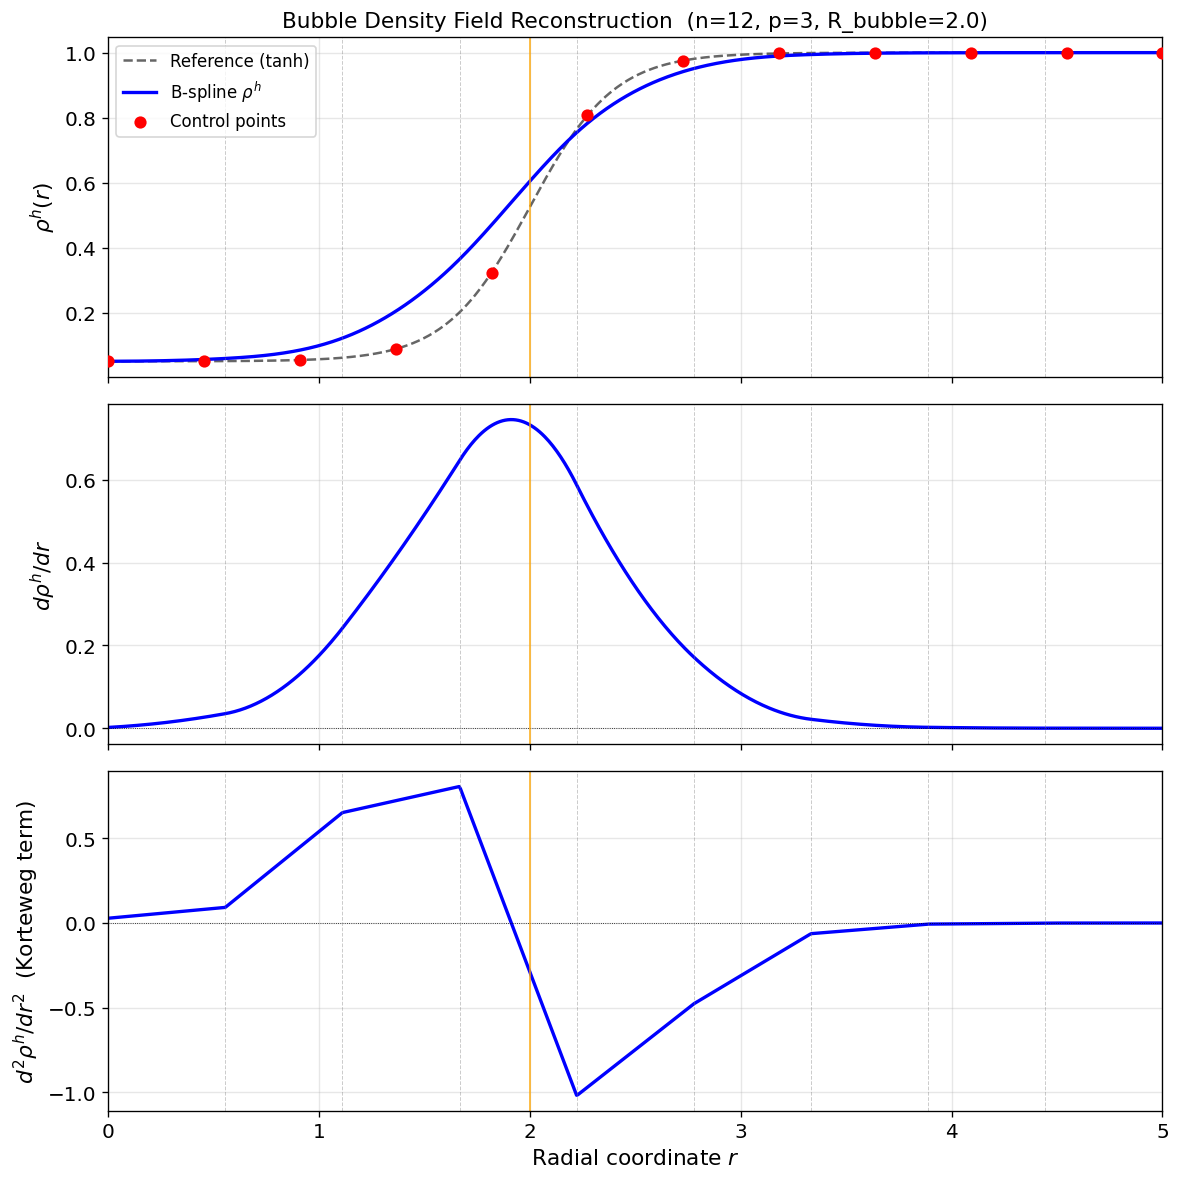

In [3]:
# Bubble profile parameters
n_ctrl   = 12
degree   = 3
R_max    = 5.0     # outer radius
R_bubble = 2.0     # bubble radius
rho_liq  = 1.0     # liquid density (normalized)
rho_vap  = 0.05    # vapor density
width    = 0.4     # interface half-width

t = make_knot_vector(n_ctrl, degree)

# Control point locations (physical)
r_ctrl = R_max * np.asarray(jnp.linspace(0.0, 1.0, n_ctrl))

# Synthetic density profile at control point locations (tanh interface)
def bubble_density(r):
    return rho_vap + (rho_liq - rho_vap) * 0.5 * (1 + np.tanh((r - R_bubble) / width))

d_ctrl = jnp.array(bubble_density(r_ctrl))

# Evaluate on fine grid
xi   = jnp.linspace(0.0, 1.0, 800)
r    = R_max * np.asarray(xi)
N    = np.asarray(basis_matrix(xi, t, degree))
dN   = np.asarray(basis_deriv_matrix(xi, t, degree, order=1)) / R_max
d2N  = np.asarray(basis_deriv_matrix(xi, t, degree, order=2)) / R_max**2

rho_h   = N   @ np.asarray(d_ctrl)
drho_h  = dN  @ np.asarray(d_ctrl)
d2rho_h = d2N @ np.asarray(d_ctrl)
rho_ref = bubble_density(r)

knot_locs = R_max * np.unique(np.asarray(t))

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# ρ
axes[0].plot(r, rho_ref, 'k--', lw=1.5, label='Reference (tanh)', alpha=0.6)
axes[0].plot(r, rho_h,   'b-',  lw=2.0, label='B-spline $\\rho^h$')
axes[0].scatter(r_ctrl, np.asarray(d_ctrl), color='red', s=40, zorder=5, label='Control points')
axes[0].set_ylabel('$\\rho^h(r)$')
axes[0].legend()

# dρ/dr
axes[1].plot(r, drho_h, 'b-', lw=2.0)
axes[1].set_ylabel('$d\\rho^h/dr$')
axes[1].axhline(0, color='k', lw=0.5, ls=':')

# d²ρ/dr² — the Korteweg stress term
axes[2].plot(r, d2rho_h, 'b-', lw=2.0)
axes[2].set_ylabel('$d^2\\rho^h/dr^2$  (Korteweg term)')
axes[2].axhline(0, color='k', lw=0.5, ls=':')
axes[2].set_xlabel('Radial coordinate $r$')

for ax in axes:
    for xk in knot_locs[1:-1]:
        ax.axvline(xk, color='gray', lw=0.6, ls='--', alpha=0.4)
    ax.axvline(R_bubble, color='orange', lw=1.2, ls='-', alpha=0.7, label='Bubble radius' if ax == axes[0] else '')
    ax.set_xlim(0, R_max)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Bubble Density Field Reconstruction  (n={n_ctrl}, p={degree}, R_bubble={R_bubble})')
plt.tight_layout()
plt.savefig('../figures/plot2_bubble_reconstruction.png', bbox_inches='tight')
plt.show()

## Plot 3: Quadrature Point Distribution
Shows element boundaries, Gauss point locations, and the $r^2$ spherical weight factor — motivates why integration near $r=0$ requires care.

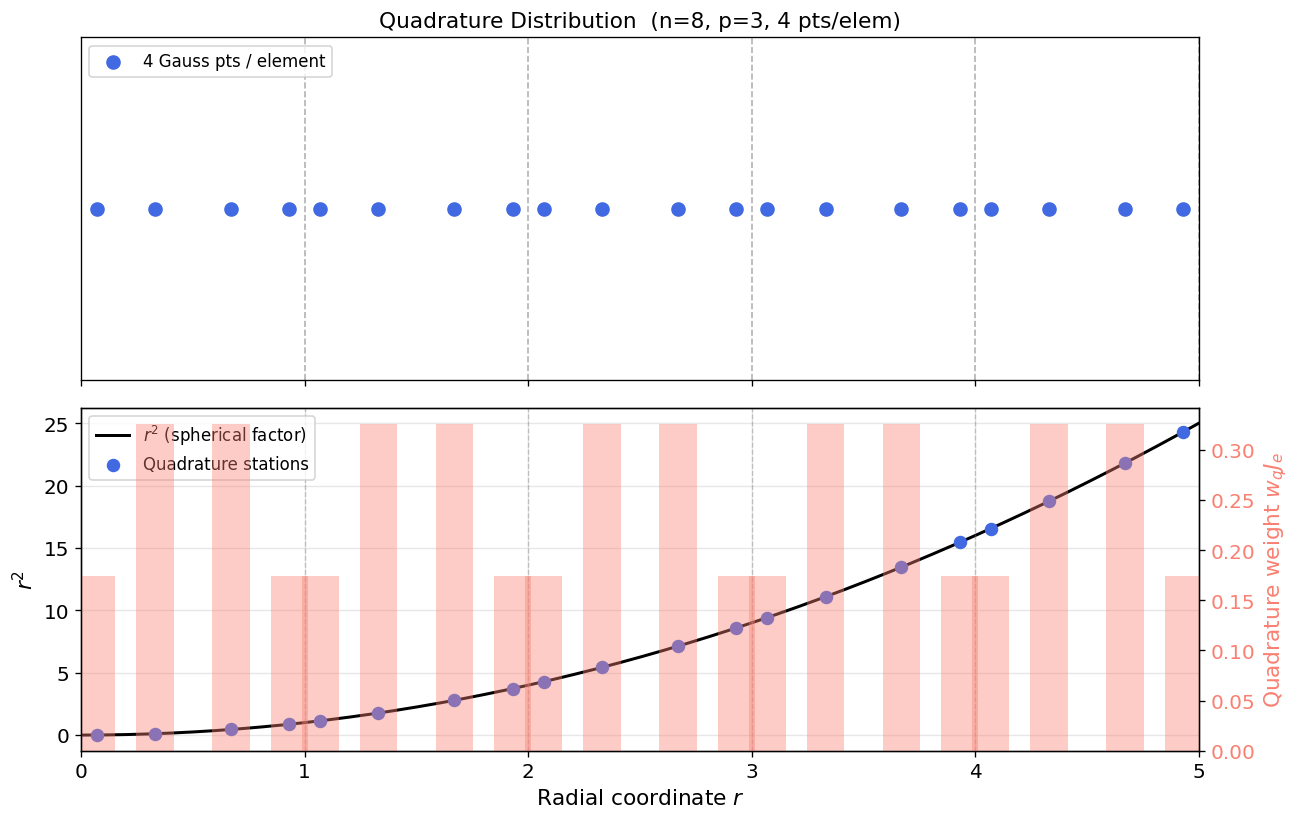

Total quadrature points: 20


In [4]:
n_ctrl = 8
degree = 3
R_max  = 5.0
n_gauss = recommended_n_gauss(degree)

t = make_knot_vector(n_ctrl, degree)
xi_q, r_q, w_q = quadrature_points(t, degree, n_gauss, R_max)
r_q_np = np.asarray(r_q)
w_q_np = np.asarray(w_q)

knot_locs = R_max * np.unique(np.asarray(t))
r_fine    = np.linspace(0, R_max, 400)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Top: quadrature point locations
for xk in knot_locs:
    axes[0].axvline(xk, color='gray', lw=1.0, ls='--', alpha=0.6)
axes[0].scatter(r_q_np, np.ones_like(r_q_np), s=60, color='royalblue',
                zorder=5, label=f'{n_gauss} Gauss pts / element')
axes[0].set_yticks([])
axes[0].set_ylim(0.5, 1.5)
axes[0].set_title(f'Quadrature Distribution  (n={n_ctrl}, p={degree}, {n_gauss} pts/elem)')
axes[0].legend(loc='upper left')

# Bottom: r² weight factor
axes[1].plot(r_fine, r_fine**2, 'k-', lw=1.8, label='$r^2$ (spherical factor)')
axes[1].scatter(r_q_np, r_q_np**2, s=50, color='royalblue', zorder=5,
                label='Quadrature stations')
# Bar chart of weights
ax2 = axes[1].twinx()
ax2.bar(r_q_np, w_q_np, width=R_max/(len(r_q_np)*1.5),
        color='salmon', alpha=0.4, label='$w_q \\cdot J_e$')
ax2.set_ylabel('Quadrature weight $w_q J_e$', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

for xk in knot_locs[1:-1]:
    axes[1].axvline(xk, color='gray', lw=0.8, ls='--', alpha=0.4)

axes[1].set_xlabel('Radial coordinate $r$')
axes[1].set_ylabel('$r^2$')
axes[1].set_xlim(0, R_max)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('../figures/plot3_quadrature.png', bbox_inches='tight')
plt.show()
print(f'Total quadrature points: {len(r_q_np)}')

## Plot 4: Effect of Degree (p=2, 3, 4)
Same control points, different polynomial degrees. Illustrates the trade-off between smoothness and local support, and confirms that only $p \geq 2$ provides the $C^1$ continuity needed for $\partial^2\rho/\partial r^2$.

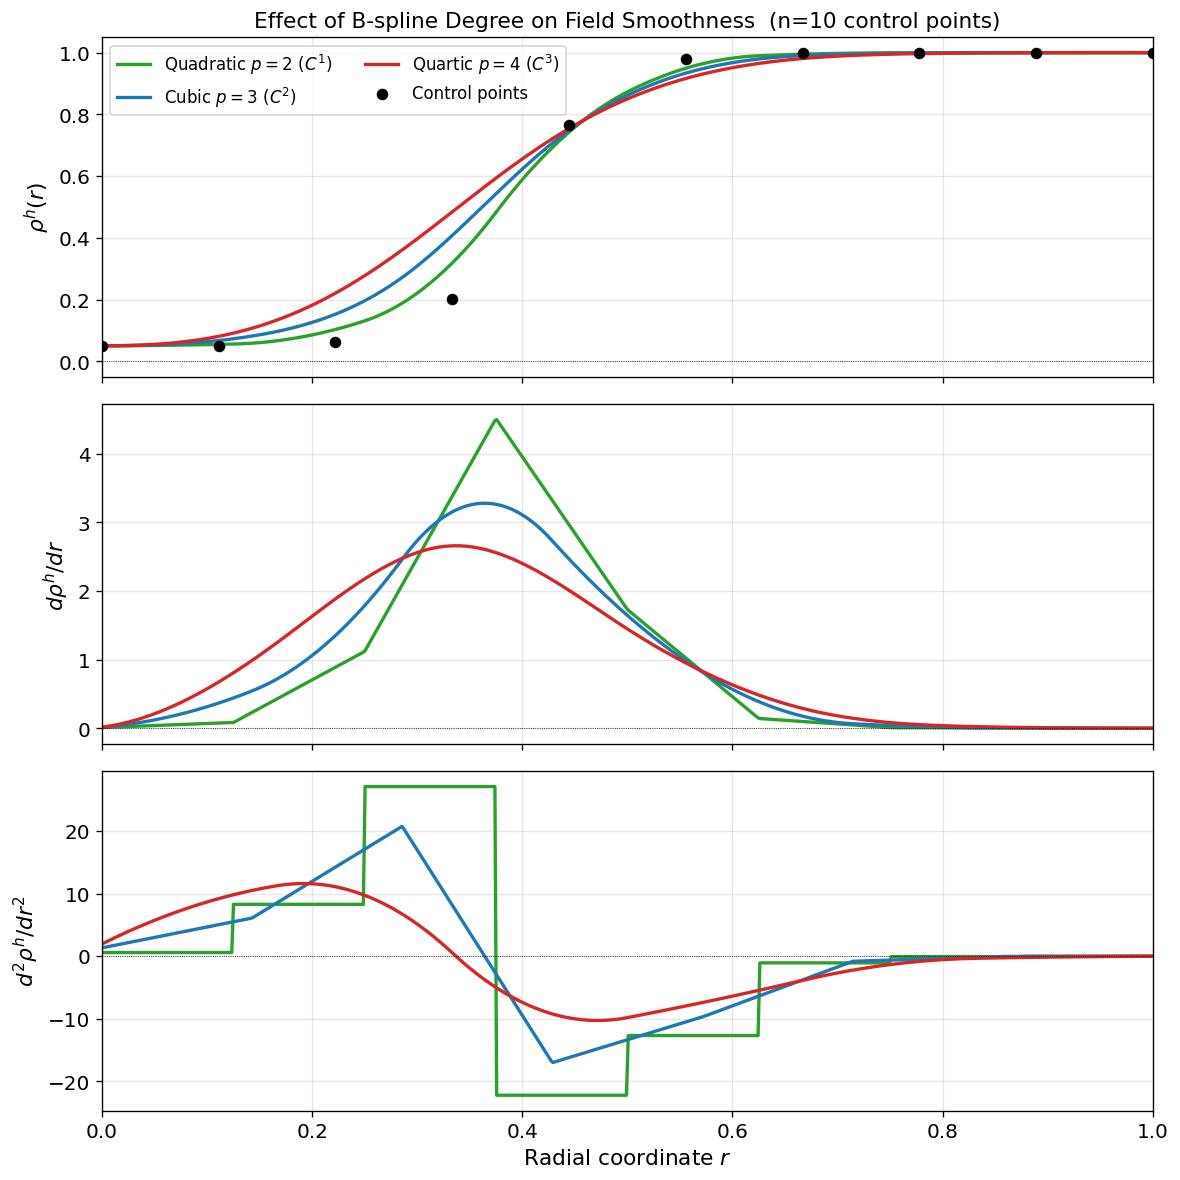

In [5]:
n_ctrl  = 10
R_max   = 1.0
degrees = [2, 3, 4]
labels  = ['Quadratic $p=2$ ($C^1$)', 'Cubic $p=3$ ($C^2$)', 'Quartic $p=4$ ($C^3$)']
colors  = ['tab:green', 'tab:blue', 'tab:red']

# Shared control point values — bubble-like profile
r_ctrl_norm = np.linspace(0, 1, n_ctrl)
d_ctrl = jnp.array(0.05 + 0.95 * 0.5 * (1 + np.tanh((r_ctrl_norm - 0.4) / 0.08)))

xi = jnp.linspace(0.0, 1.0, 600)
r  = np.asarray(xi) * R_max

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
row_labels = ['$\\rho^h(r)$', '$d\\rho^h/dr$', '$d^2\\rho^h/dr^2$']

for deg, label, color in zip(degrees, labels, colors):
    t    = make_knot_vector(n_ctrl, deg)
    N    = np.asarray(basis_matrix(xi, t, deg))
    dN   = np.asarray(basis_deriv_matrix(xi, t, deg, order=1)) / R_max
    d2N  = np.asarray(basis_deriv_matrix(xi, t, deg, order=2)) / R_max**2
    d_np = np.asarray(d_ctrl)

    axes[0].plot(r, N   @ d_np, color=color, lw=2.0, label=label)
    axes[1].plot(r, dN  @ d_np, color=color, lw=2.0)
    axes[2].plot(r, d2N @ d_np, color=color, lw=2.0)

# Control points
axes[0].scatter(r_ctrl_norm * R_max, np.asarray(d_ctrl),
                color='black', s=35, zorder=5, label='Control points')

for ax, ylabel in zip(axes, row_labels):
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, R_max)
    ax.grid(True, alpha=0.3)

axes[0].legend(ncol=2)
axes[0].set_title(f'Effect of B-spline Degree on Field Smoothness  (n={n_ctrl} control points)')
axes[2].set_xlabel('Radial coordinate $r$')

plt.tight_layout()
plt.savefig('../figures/plot4_degree_comparison.png', bbox_inches='tight')
plt.show()